<a href="https://colab.research.google.com/github/e-junior/Grupo16TechChallenge/blob/main/dtech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
exp_vinho = pd.read_csv('ExpVinhoPivot.csv')

In [3]:
exp_vinho.head()

,Id,País,Ano,Quantidade,Valor (USD)
0,1,Afeganistão,1970,0,0
1,1,Afeganistão,1971,0,0
2,1,Afeganistão,1972,0,0
3,1,Afeganistão,1973,0,0
4,1,Afeganistão,1974,0,0


In [4]:
type(exp_vinho)

pandas.core.frame.DataFrame

In [5]:
exp_vinho.shape


(7755, 5)

In [6]:
exp_vinho.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7755 entries, 0 to 7754
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Id           7755 non-null   int64 
 1   País         7755 non-null   object
 2   Ano          7755 non-null   int64 
 3   Quantidade   7755 non-null   int64 
 4   Valor (USD)  7755 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 303.1+ KB


In [7]:
exp_vinho.columns

Index(['Id', 'País', 'Ano', 'Quantidade', 'Valor (USD)'], dtype='object')

In [8]:
exp_vinho.columns = [ 'id', 'pais', 'ano', 'quantidade', 'usd']

In [9]:
exp_vinho.dtypes

,0
id,int64
pais,object
ano,int64
quantidade,int64
usd,int64


In [10]:
exp_vinho['ano'] = exp_vinho['ano'].astype(str)

função-filtro para anos maiores que 2007

In [11]:
# função filtro para anos maiores que 2007

def filtrar_por_ano(df_inicial, nome_coluna_ano, ano_de_corte):
    """
    Filtra um DataFrame para manter apenas os dados a partir de um determinado ano.

    Argumentos:
        df_inicial (pd.DataFrame): A tabela que você quer filtrar.
        nome_coluna_ano (str): O nome da coluna que contém os anos (ex: 'Ano').
        ano_de_corte (int): O último ano a ser removido. A função manterá
                             todos os dados ONDE ano > ano_de_corte.

    Retorna:
        pd.DataFrame: Um novo DataFrame contendo apenas os dados filtrados.
    """
    print(f"Filtrando a tabela para manter apenas os anos posteriores a {ano_de_corte}...")

    # Realiza a filtragem e cria uma cópia para evitar avisos do pandas
    df_filtrado = df_inicial[df_inicial[nome_coluna_ano] > ano_de_corte].copy()

    if df_filtrado.empty:
        print("Atenção: Nenhum dado encontrado após o ano de corte.")
        return None

    #print("Filtragem concluída com sucesso.")
    print('=================================================================')
    return df_filtrado


In [12]:
exp_vinho_filtrado = filtrar_por_ano(
    df_inicial = exp_vinho,
    nome_coluna_ano='ano',
    ano_de_corte='2007'
)

Filtrando a tabela para manter apenas os anos posteriores a 2007...


In [13]:
exp_vinho_filtrado.describe()


,id,quantidade,usd
count,2397.000000,2.397000e+03,2.397000e+03
mean,71.000000,4.123729e+04,5.436740e+04
std,40.710663,5.470190e+05,4.730460e+05
min,1.000000,0.000000e+00,0.000000e+00
25%,36.000000,0.000000e+00,0.000000e+00
50%,71.000000,0.000000e+00,0.000000e+00
75%,106.000000,7.360000e+02,2.995000e+03
max,141.000000,2.191291e+07,1.479569e+07


Text(0, 0.5, 'Países')

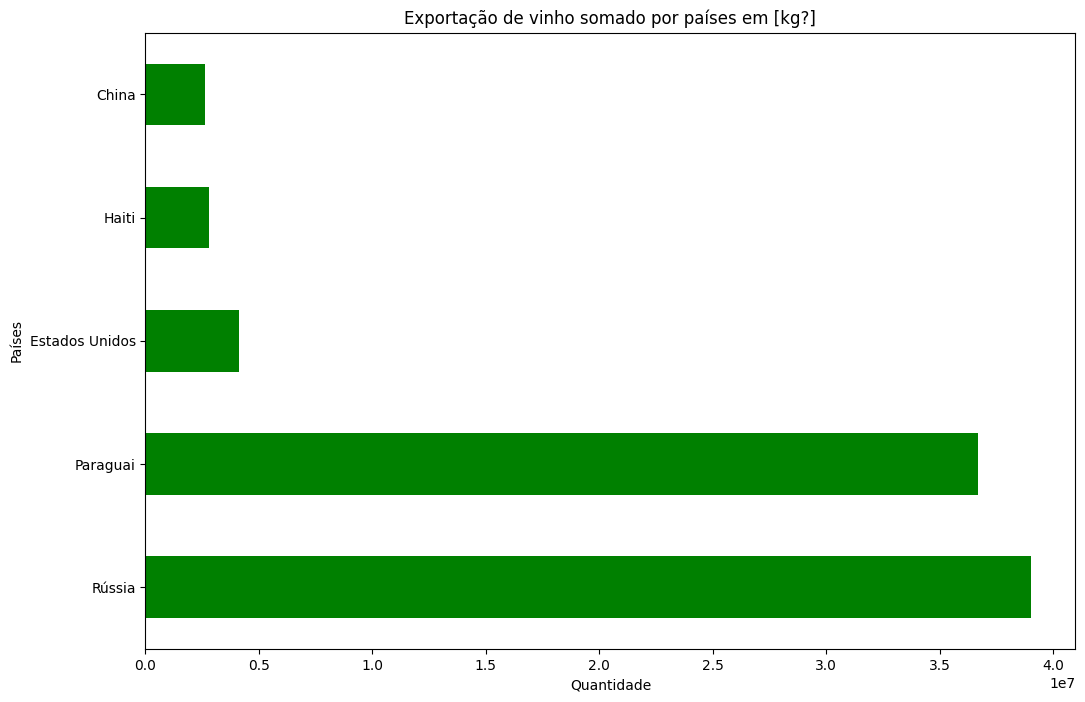

In [30]:
#Exportação em volume dos últimos 15 anos
exp_vinho_qtd = exp_vinho_filtrado.groupby(['pais'])['quantidade'].sum().sort_values(ascending = False).head(5)

exp_vinho_qtd.plot(kind='barh', figsize = (12,8), color = 'green')
plt.title('Exportação de vinho somado por países em [kg?]')
plt.xlabel('Quantidade')
plt.ylabel('Países')

Text(0, 0.5, 'Países')

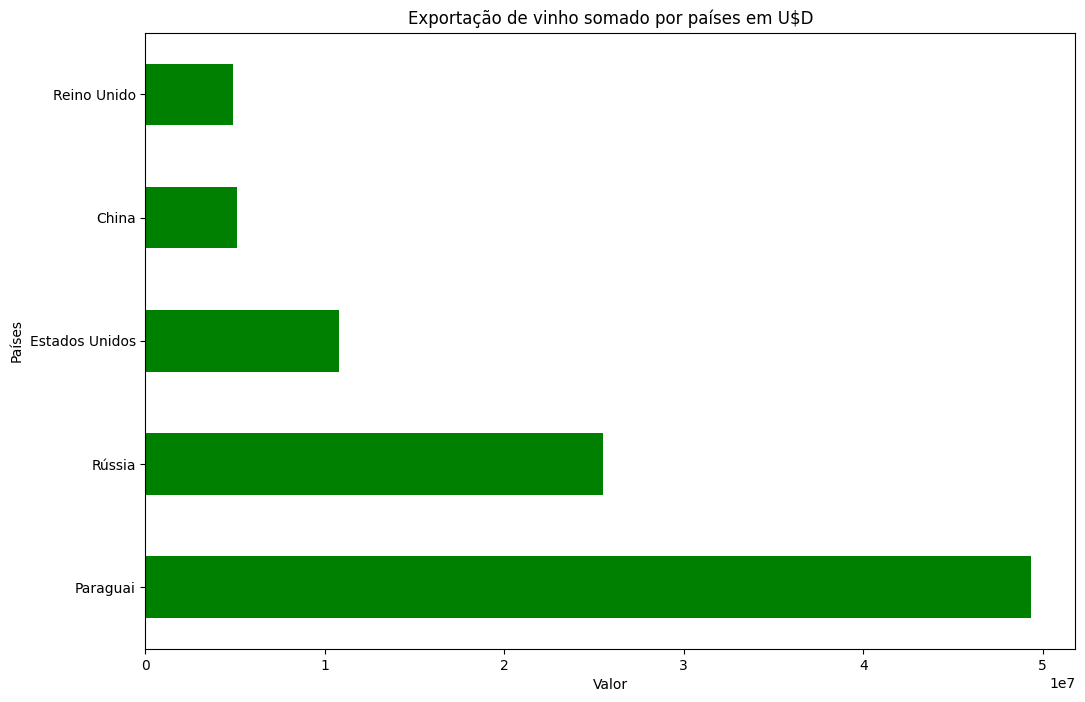

In [31]:
#Exportação em volume dos últimos 15 anos
exp_vinho_valor = exp_vinho_filtrado.groupby(['pais'])['usd'].sum().sort_values(ascending = False).head(5)

exp_vinho_valor.plot(kind='barh', figsize = (12,8), color = 'green')
plt.title('Exportação de vinho somado por países em U$D')
plt.xlabel('Valor')
plt.ylabel('Países')